In [88]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# make src/ importable when running notebook from notebooks/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DIR, INTERIM_DIR
from src.utils import standardize_columns, preview

In [2]:
print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("Interim dir:", INTERIM_DIR)

Project root: /Users/mihirgaudani/trader-joes-nyc-case-study
Raw dir: /Users/mihirgaudani/trader-joes-nyc-case-study/data/raw
Interim dir: /Users/mihirgaudani/trader-joes-nyc-case-study/data/interim


In [3]:
print("Current raw files:", list(RAW_DIR.iterdir()))

Current raw files: [PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/nyc_borough_boundaries.geojson'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/trader_joes_nyc.csv'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/wegmans_nyc.csv'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/tl_2022_us_zcta520.zip'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/zip_demographics.csv'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/.gitkeep'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/whole_foods_nyc.csv'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/commercial_rent_top10.csv'), PosixPath('/Users/mihirgaudani/trader-joes-nyc-case-study/data/raw/nyc_subway_stations.csv')]


In [4]:
import geopandas as gpd
zcta_gdf = gpd.read_file(RAW_DIR / "tl_2022_us_zcta520.zip")
boroughs_gdf = gpd.read_file(RAW_DIR / "nyc_borough_boundaries.geojson")

zcta_gdf = standardize_columns(zcta_gdf)
boroughs_gdf = standardize_columns(boroughs_gdf)

zcta_gdf = zcta_gdf.to_crs(boroughs_gdf.crs)


zcta_centroids = zcta_gdf.copy()
zcta_centroids["geometry"] = zcta_centroids.geometry.centroid

zcta_borough = gpd.sjoin(
    zcta_centroids,
    boroughs_gdf[["boroname", "geometry"]],
    how="inner",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

zcta_borough = zcta_borough.drop_duplicates(subset=["zcta5ce20"]).copy()


nyc_zcta_gdf = zcta_gdf.merge(
    zcta_borough[["zcta5ce20", "boroname"]],
    on="zcta5ce20",
    how="inner"
)

nyc_zcta_gdf["zip_code"] = nyc_zcta_gdf["zcta5ce20"].astype(str).str.zfill(5)

nyc_zcta_gdf[["zip_code", "boroname"]].head()

/var/folders/yy/hmg9n8354mj787grvg19x4ch0000gn/T/ipykernel_70212/3286719451.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zcta_centroids["geometry"] = zcta_centroids.geometry.centroid


,zip_code,boroname
0,10028,Manhattan
1,11427,Queens
2,11697,Queens
3,11004,Queens
4,10282,Manhattan


Draft 1: \
zcta_gdf = gpd.read_file(RAW_DIR / "tl_2022_us_zcta520.zip")
boroughs_gdf = gpd.read_file(RAW_DIR / "nyc_borough_boundaries.geojson")

zcta_gdf = zcta_gdf.to_crs(boroughs_gdf.crs)

nyc_zcta_gdf = gpd.sjoin(
    zcta_gdf,
    boroughs_gdf,
    how="inner",
    predicate="intersects"
).drop(columns=["index_right"], errors="ignore")

In [5]:
nyc_zcta_gdf['boroname'].unique()

<StringArray>
['Manhattan', 'Queens', 'Bronx', 'Brooklyn', 'Staten Island']
Length: 5, dtype: str

In [6]:
nyc_zcta_gdf.columns

Index(['zcta5ce20', 'geoid20', 'classfp20', 'mtfcc20', 'funcstat20', 'aland20',
       'awater20', 'intptlat20', 'intptlon20', 'geometry', 'boroname',
       'zip_code'],
      dtype='str')

In [7]:
nyc_zcta_gdf = standardize_columns(nyc_zcta_gdf)
nyc_zcta_gdf.columns

Index(['zcta5ce20', 'geoid20', 'classfp20', 'mtfcc20', 'funcstat20', 'aland20',
       'awater20', 'intptlat20', 'intptlon20', 'geometry', 'boroname',
       'zip_code'],
      dtype='str')

In [8]:
nyc_zcta_gdf["zip_code"] = nyc_zcta_gdf["zcta5ce20"].astype(str).str.zfill(5)
nyc_zcta_gdf[["zip_code", "boroname"]].head()

,zip_code,boroname
0,10028,Manhattan
1,11427,Queens
2,11697,Queens
3,11004,Queens
4,10282,Manhattan


In [9]:
nyc_zcta_gdf["zip_code"].duplicated().sum()

np.int64(0)

In [10]:
nyc_zcta_gdf.to_file(INTERIM_DIR / "nyc_zcta_clean.geojson", driver="GeoJSON")

In [11]:
import requests

ACS_url = (
    "https://api.census.gov/data/2023/acs/acs5"
    "?get=NAME,B01003_001E,B19013_001E"
    "&for=zip%20code%20tabulation%20area:*"
)

response = requests.get(ACS_url)
response.raise_for_status()

data = response.json()

demo_df = pd.DataFrame(data[1:], columns=data[0])
demo_df = standardize_columns(demo_df)

demo_df = demo_df.rename(columns={
    "b01003_001e": "total_population",
    "b19013_001e": "median_household_income",
    "zip_code_tabulation_area": "zip_code"
})

demo_df["zip_code"] = demo_df["zip_code"].astype(str).str.zfill(5)
demo_df["total_population"] = pd.to_numeric(demo_df["total_population"], errors="coerce")
demo_df["median_household_income"] = pd.to_numeric(demo_df["median_household_income"], errors="coerce")
demo_df["median_household_income"] = demo_df["median_household_income"].replace(-666666666, pd.NA)
demo_df["median_household_income"] = pd.to_numeric(demo_df["median_household_income"], errors="coerce")

nyc_demo_gdf = nyc_zcta_gdf.merge(demo_df, on="zip_code", how="left")

keep_cols = [
    "zip_code",
    "geoid20",
    "boroname",
    "total_population",
    "median_household_income",
    "geometry"
]

nyc_demo_gdf = nyc_demo_gdf[keep_cols].copy()
nyc_demo_gdf.head()

,zip_code,geoid20,boroname,total_population,median_household_income,geometry
0,10028,10028,Manhattan,45679,168125.0,"POLYGON ((-73.96277 40.77831, -73.9623 40.7789..."
1,11427,11427,Queens,25124,92129.0,"POLYGON ((-73.76624 40.7264, -73.76546 40.7264..."
2,11697,11697,Queens,4123,134844.0,"POLYGON ((-73.94074 40.54182, -73.94013 40.548..."
3,11004,11004,Queens,14296,109865.0,"POLYGON ((-73.72273 40.75435, -73.72255 40.754..."
4,10282,10282,Manhattan,5960,250001.0,"POLYGON ((-74.01742 40.71495, -74.01671 40.718..."


Draft 1 \
demo_df = standardize_columns(demo_df)

demo_df = demo_df.rename(
    columns={
        "b01003_001e": "total_population",
        "b19013_001e": "median_household_income",
        "zip_code_tabulation_area": "zip_code"
    }
)

demo_df["zip_code"] = demo_df["zip_code"].astype(str).str.zfill(5)

demo_df["total_population"] = pd.to_numeric(demo_df["total_population"], errors="coerce")
demo_df["median_household_income"] = pd.to_numeric(demo_df["median_household_income"], errors="coerce")

preview(demo_df, "ACS ZIP Demographics")
demo_df.head()

In [12]:
nyc_demo_gdf["zip_code"].duplicated().sum()

np.int64(0)

In [13]:
demo_df.to_csv(RAW_DIR / "zip_demographics.csv", index=False)

In [14]:
nyc_demo_gdf = nyc_zcta_gdf.merge(demo_df, on="zip_code", how="left")

preview(nyc_demo_gdf, "NYC ZCTA + ACS")
nyc_demo_gdf[["zip_code", "boroname", "total_population", "median_household_income"]].head()

NYC ZCTA + ACS: 206 rows x 15 cols
  zcta5ce20 geoid20 classfp20 mtfcc20 funcstat20  aland20  awater20  \
0     10028   10028        B5   G6350          S   817182         0   
1     11427   11427        B5   G6350          S  4062875         0   
2     11697   11697        B5   G6350          S  5302645         0   
3     11004   11004        B5   G6350          S  2463268         0   
4     10282   10282        B5   G6350          S   177847         0   

    intptlat20    intptlon20  \
0  +40.7764466  -073.9533832   
1  +40.7309425  -073.7457159   
2  +40.5571317  -073.9137216   
3  +40.7461911  -073.7115068   
4  +40.7163808  -074.0150041   

                                            geometry   boroname zip_code  \
0  POLYGON ((-73.96277 40.77831, -73.9623 40.7789...  Manhattan    10028   
1  POLYGON ((-73.76624 40.7264, -73.76546 40.7264...     Queens    11427   
2  POLYGON ((-73.94074 40.54182, -73.94013 40.548...     Queens    11697   
3  POLYGON ((-73.72273 40.75435, -73.7225

,zip_code,boroname,total_population,median_household_income
0,10028,Manhattan,45679,168125.0
1,11427,Queens,25124,92129.0
2,11697,Queens,4123,134844.0
3,11004,Queens,14296,109865.0
4,10282,Manhattan,5960,250001.0


In [15]:
nyc_demo_gdf["total_population"].notna().mean()

np.float64(1.0)

In [16]:
keep_cols = [
    "zip_code",
    "geoid20",
    "boroname",
    "total_population",
    "median_household_income",
    "geometry"
]

nyc_demo_gdf = nyc_demo_gdf[keep_cols].copy()
nyc_demo_gdf.head()

,zip_code,geoid20,boroname,total_population,median_household_income,geometry
0,10028,10028,Manhattan,45679,168125.0,"POLYGON ((-73.96277 40.77831, -73.9623 40.7789..."
1,11427,11427,Queens,25124,92129.0,"POLYGON ((-73.76624 40.7264, -73.76546 40.7264..."
2,11697,11697,Queens,4123,134844.0,"POLYGON ((-73.94074 40.54182, -73.94013 40.548..."
3,11004,11004,Queens,14296,109865.0,"POLYGON ((-73.72273 40.75435, -73.72255 40.754..."
4,10282,10282,Manhattan,5960,250001.0,"POLYGON ((-74.01742 40.71495, -74.01671 40.718..."


In [17]:
nyc_demo_gdf.to_file(INTERIM_DIR / "nyc_zcta_demographics.geojson", driver="GeoJSON")

In [18]:
nyc_demo_gdf.drop(columns="geometry").to_csv(
    INTERIM_DIR / "nyc_zcta_demographics.csv",
    index=False
)

In [19]:
tj_df = pd.read_csv(RAW_DIR / "trader_joes_nyc.csv")
tj_df = standardize_columns(tj_df)
tj_df["zip_code"] = tj_df["zip_code"].astype(str).str.zfill(5)
tj_df.head()

,store_name,address,borough,zip_code
0,72nd & Broadway (542),2073 Broadway,Manhattan,10023
1,Chelsea (543),675 6th Ave,Manhattan,10010
2,East Village (546),436 East 14th St,Manhattan,10009
3,Essex Crossing (538),400 Grand St. (Cellar),Manhattan,10002
4,Harlem (576),123 W 125th St,Manhattan,10027


In [20]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [21]:
geolocator = Nominatim(user_agent="trader_joes_case_study")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

tj_df["full_address"] = (
    tj_df["address"] + ", " + tj_df["borough"] + ", NY " + tj_df["zip_code"]
)

tj_df["location"] = tj_df["full_address"].apply(geocode)
tj_df["latitude"] = tj_df["location"].apply(lambda loc: loc.latitude if loc else None)
tj_df["longitude"] = tj_df["location"].apply(lambda loc: loc.longitude if loc else None)

tj_df[["store_name", "full_address", "latitude", "longitude"]]

,store_name,full_address,latitude,longitude
0,72nd & Broadway (542),"2073 Broadway, Manhattan, NY 10023",40.778593,-73.982276
1,Chelsea (543),"675 6th Ave, Manhattan, NY 10010",40.742073,-73.993677
2,East Village (546),"436 East 14th St, Manhattan, NY 10009",40.730509,-73.981099
3,Essex Crossing (538),"400 Grand St. (Cellar), Manhattan, NY 10002",NaN,NaN
4,Harlem (576),"123 W 125th St, Manhattan, NY 10027",40.808147,-73.946147
5,New York - Murray Hill (544),"200 E 32nd St, Manhattan, NY 10016",40.743929,-73.979023
6,SoHo (539),"233 Spring Street, Manhattan, NY 10013",40.725709,-74.004837
7,Union Square (540),"142 E 14th St, Manhattan, NY 10003",40.733421,-73.987875
8,Upper East Side - Bridgemarket (571),"405 E. 59th Street, Manhattan, NY 10022",40.759659,-73.961334
9,Upper West Side (545),"670 Columbus Ave, Manhattan, NY 10025",40.790866,-73.969238


In [22]:
tj_df[tj_df["latitude"].isna()][["store_name", "full_address"]]

,store_name,full_address
3,Essex Crossing (538),"400 Grand St. (Cellar), Manhattan, NY 10002"


In [23]:
tj_df.loc[tj_df["store_name"] == "Essex Crossing (538)", "full_address"] = \
    "400 Grand St, Manhattan, NY 10002"

In [24]:
missing_mask = tj_df["latitude"].isna() | tj_df["longitude"].isna()

tj_df.loc[missing_mask, "location"] = tj_df.loc[missing_mask, "full_address"].apply(geocode)
tj_df.loc[missing_mask, "latitude"] = tj_df.loc[missing_mask, "location"].apply(
    lambda loc: loc.latitude if loc else None
)
tj_df.loc[missing_mask, "longitude"] = tj_df.loc[missing_mask, "location"].apply(
    lambda loc: loc.longitude if loc else None
)

In [25]:
tj_df[tj_df["latitude"].isna()][["store_name", "full_address"]]

,store_name,full_address


In [26]:
tj_gdf = gpd.GeoDataFrame(
    tj_df,
    geometry=gpd.points_from_xy(tj_df["longitude"], tj_df["latitude"]),
    crs="EPSG:4326"
)

tj_gdf.head()

,store_name,address,borough,zip_code,full_address,location,latitude,longitude,geometry
0,72nd & Broadway (542),2073 Broadway,Manhattan,10023,"2073 Broadway, Manhattan, NY 10023","(Trader Joe's, 2073, Broadway, Manhattan Commu...",40.778593,-73.982276,POINT (-73.98228 40.77859)
1,Chelsea (543),675 6th Ave,Manhattan,10010,"675 6th Ave, Manhattan, NY 10010","(Michaels, 675, 6th Avenue, Chelsea District, ...",40.742073,-73.993677,POINT (-73.99368 40.74207)
2,East Village (546),436 East 14th St,Manhattan,10009,"436 East 14th St, Manhattan, NY 10009","(Trader Joe's, 436, East 14th Street, East Vil...",40.730509,-73.981099,POINT (-73.9811 40.73051)
3,Essex Crossing (538),400 Grand St. (Cellar),Manhattan,10002,"400 Grand St, Manhattan, NY 10002","(Trader Joe's, 400, Grand Street, Lower East S...",40.716159,-73.986726,POINT (-73.98673 40.71616)
4,Harlem (576),123 W 125th St,Manhattan,10027,"123 W 125th St, Manhattan, NY 10027","(123, West 125th Street, Harlem, Manhattan Com...",40.808147,-73.946147,POINT (-73.94615 40.80815)


In [27]:
tj_gdf = gpd.GeoDataFrame(
    tj_df,
    geometry=gpd.points_from_xy(tj_df["longitude"], tj_df["latitude"]),
    crs="EPSG:4326"
)

tj_gdf.head()

,store_name,address,borough,zip_code,full_address,location,latitude,longitude,geometry
0,72nd & Broadway (542),2073 Broadway,Manhattan,10023,"2073 Broadway, Manhattan, NY 10023","(Trader Joe's, 2073, Broadway, Manhattan Commu...",40.778593,-73.982276,POINT (-73.98228 40.77859)
1,Chelsea (543),675 6th Ave,Manhattan,10010,"675 6th Ave, Manhattan, NY 10010","(Michaels, 675, 6th Avenue, Chelsea District, ...",40.742073,-73.993677,POINT (-73.99368 40.74207)
2,East Village (546),436 East 14th St,Manhattan,10009,"436 East 14th St, Manhattan, NY 10009","(Trader Joe's, 436, East 14th Street, East Vil...",40.730509,-73.981099,POINT (-73.9811 40.73051)
3,Essex Crossing (538),400 Grand St. (Cellar),Manhattan,10002,"400 Grand St, Manhattan, NY 10002","(Trader Joe's, 400, Grand Street, Lower East S...",40.716159,-73.986726,POINT (-73.98673 40.71616)
4,Harlem (576),123 W 125th St,Manhattan,10027,"123 W 125th St, Manhattan, NY 10027","(123, West 125th Street, Harlem, Manhattan Com...",40.808147,-73.946147,POINT (-73.94615 40.80815)


In [28]:
tj_gdf.to_file(INTERIM_DIR / "trader_joes_locations.geojson", driver="GeoJSON")
tj_df.drop(columns=["location"], errors="ignore").to_csv(
    INTERIM_DIR / "trader_joes_locations.csv",
    index=False
)

In [29]:
tj_df.shape

(18, 8)

In [30]:
tj_df[["store_name", "latitude", "longitude"]].isna().sum()


store_name    0
latitude      0
longitude     0
dtype: int64

In [31]:
tj_df[tj_df["latitude"].isna() | tj_df["longitude"].isna()][
    ["store_name", "full_address"]
]

,store_name,full_address


In [32]:
tj_df["store_name"].duplicated().sum()

np.int64(0)

In [33]:
tj_df[["latitude", "longitude"]].describe()

,latitude,longitude
count,18.000000,18.000000
mean,40.717760,-73.987216
std,0.067626,0.086077
min,40.521688,-74.216905
25%,40.712391,-73.991610
50%,40.728109,-73.981687
75%,40.745368,-73.962508
max,40.808147,-73.848109


In [34]:
tj_gdf.geometry.isna().sum()

np.int64(0)

In [35]:
tj_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

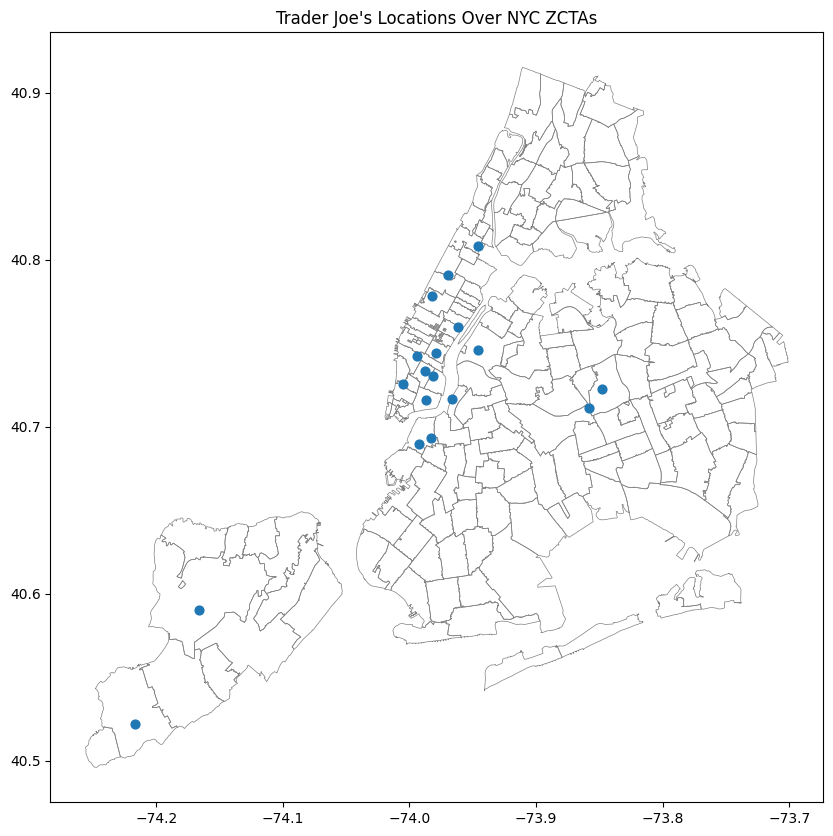

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))

nyc_demo_gdf.to_crs(epsg=4326).plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.5
)

tj_gdf.plot(ax=ax, markersize=40)

plt.title("Trader Joe's Locations Over NYC ZCTAs")
plt.show()

In [37]:
tj_df[["store_name", "borough", "zip_code", "latitude", "longitude"]].sort_values(["borough", "store_name"])

,store_name,borough,zip_code,latitude,longitude
12,Brooklyn (558),Brooklyn,11201,40.689521,-73.992856
10,Brooklyn - City Point (547),Brooklyn,11201,40.693314,-73.983381
11,Brooklyn - Williamsburg (548),Brooklyn,11249,40.716489,-73.966031
0,72nd & Broadway (542),Manhattan,10023,40.778593,-73.982276
1,Chelsea (543),Manhattan,10010,40.742073,-73.993677
2,East Village (546),Manhattan,10009,40.730509,-73.981099
3,Essex Crossing (538),Manhattan,10002,40.716159,-73.986726
4,Harlem (576),Manhattan,10027,40.808147,-73.946147
5,New York - Murray Hill (544),Manhattan,10016,40.743929,-73.979023
6,SoHo (539),Manhattan,10013,40.725709,-74.004837


In [38]:
nyc_zcta_proj = nyc_demo_gdf.to_crs(epsg=2263)
tj_proj = tj_gdf.to_crs(epsg=2263)

In [39]:
centroids = nyc_zcta_proj.geometry.centroid


In [40]:
nyc_zcta_proj["nearest_tj_distance_ft"] = centroids.apply(
    lambda pt: tj_proj.geometry.distance(pt).min()
)

In [41]:
nyc_zcta_proj["nearest_tj_distance_miles"] = nyc_zcta_proj["nearest_tj_distance_ft"] / 5280


In [42]:
nyc_zcta_proj[[
    "zip_code",
    "boroname",
        "nearest_tj_distance_ft",
    "nearest_tj_distance_miles"
]].head()


,zip_code,boroname,nearest_tj_distance_ft,nearest_tj_distance_miles
0,10028,Manhattan,6500.867327,1.231225
1,11427,Queens,28540.686549,5.405433
2,11697,Queens,52999.852120,10.037851
3,11004,Queens,38817.224905,7.351747
4,10282,Manhattan,4415.011460,0.836176


In [43]:
nyc_zcta_save = nyc_zcta_proj.drop(columns=["centroid"], errors="ignore").copy()

nyc_zcta_save.to_file(
    INTERIM_DIR / "nyc_zcta_demographics_with_tj_distance.geojson",
    driver="GeoJSON"
)

nyc_zcta_save.drop(columns=["geometry"], errors="ignore").to_csv(
    INTERIM_DIR / "nyc_zcta_demographics_with_tj_distance.csv",
    index=False
)

In [44]:
subway_df = pd.read_csv(RAW_DIR / "nyc_subway_stations.csv")
subway_df = standardize_columns(subway_df)
subway_df.head()

,gtfs_stop_id,station_id,complex_id,division,line,stop_name,borough,cbd,daytime_routes,structure,gtfs_latitude,gtfs_longitude,north_direction_label,south_direction_label,ada,ada_northbound,ada_southbound,ada_notes,georeference
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804)


In [45]:
subway_df.columns

Index(['gtfs_stop_id', 'station_id', 'complex_id', 'division', 'line',
       'stop_name', 'borough', 'cbd', 'daytime_routes', 'structure',
       'gtfs_latitude', 'gtfs_longitude', 'north_direction_label',
       'south_direction_label', 'ada', 'ada_northbound', 'ada_southbound',
       'ada_notes', 'georeference'],
      dtype='str')

In [46]:
subway_gdf = gpd.GeoDataFrame(
    subway_df,
    geometry=gpd.points_from_xy(
        subway_df["gtfs_longitude"],
        subway_df["gtfs_latitude"]
    ),
    crs="EPSG:4326"
)

subway_gdf.head()

,gtfs_stop_id,station_id,complex_id,division,line,stop_name,borough,cbd,daytime_routes,structure,gtfs_latitude,gtfs_longitude,north_direction_label,south_direction_label,ada,ada_northbound,ada_southbound,ada_notes,georeference,geometry
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036),POINT (-73.91203 40.77504)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258),POINT (-73.91784 40.77026)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779),POINT (-73.92148 40.76678)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182),POINT (-73.92551 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804),POINT (-73.92958 40.7568)


In [47]:
zcta_for_join = nyc_demo_gdf.to_crs(epsg=4326).copy()
subway_for_join = subway_gdf.to_crs(epsg=4326).copy()

station_join = gpd.sjoin(
    subway_for_join,
    zcta_for_join[["zip_code", "geometry"]],
    how="left",
    predicate="within"
)

station_counts = (
    station_join.groupby("zip_code")
    .size()
    .reset_index(name="subway_station_count")
)

station_counts.head()

,zip_code,subway_station_count
0,10001,7
1,10002,5
2,10003,7
3,10005,3
4,10006,3


In [48]:
nyc_features_gdf = nyc_demo_gdf.merge(station_counts, on="zip_code", how="left")
nyc_features_gdf["subway_station_count"] = nyc_features_gdf["subway_station_count"].fillna(0)

nyc_features_gdf[[
    "zip_code",
    "boroname",
    "total_population",
    "median_household_income",
    "subway_station_count"
]].sort_values('subway_station_count', ascending = False)

,zip_code,boroname,total_population,median_household_income,subway_station_count
90,11101,Queens,39007,116807.0,13.0
10,11207,Brooklyn,93445,55419.0,12.0
14,11201,Brooklyn,69251,169285.0,12.0
59,11206,Brooklyn,89231,57280.0,9.0
195,10011,Manhattan,49344,146571.0,8.0
...,...,...,...,...,...
78,10153,Manhattan,0,NaN,0.0
132,11357,Queens,42341,97754.0,0.0
131,10174,Manhattan,0,NaN,0.0
129,10173,Manhattan,0,NaN,0.0


In [49]:
nyc_features_gdf["zip_code"].duplicated().sum()

np.int64(0)

In [50]:
nyc_features_gdf["median_household_income"].describe()


count       176.000000
mean      96272.096591
std       44259.593029
min       27500.000000
25%       66012.750000
50%       86543.000000
75%      112267.000000
max      250001.000000
Name: median_household_income, dtype: float64

In [51]:
nyc_features_gdf["median_household_income"].isna().sum()

np.int64(30)

In [52]:
nyc_features_gdf["median_household_income"] = pd.to_numeric(
    nyc_features_gdf["median_household_income"],
    errors="coerce"
)

In [53]:
nyc_features_gdf["median_household_income"].describe()

count       176.000000
mean      96272.096591
std       44259.593029
min       27500.000000
25%       66012.750000
50%       86543.000000
75%      112267.000000
max      250001.000000
Name: median_household_income, dtype: float64

In [54]:
nyc_features_gdf.columns

Index(['zip_code', 'geoid20', 'boroname', 'total_population',
       'median_household_income', 'geometry', 'subway_station_count'],
      dtype='str')

In [55]:
nyc_zcta_proj[["zip_code", "nearest_tj_distance_miles"]].head()

,zip_code,nearest_tj_distance_miles
0,10028,1.231225
1,11427,5.405433
2,11697,10.037851
3,11004,7.351747
4,10282,0.836176


In [56]:
nyc_features_gdf = nyc_zcta_proj.merge(station_counts, on="zip_code", how="left")
nyc_features_gdf["subway_station_count"] = nyc_features_gdf["subway_station_count"].fillna(0)

In [57]:
nyc_features_gdf[[
    "zip_code",
    "boroname",
    "total_population",
    "median_household_income",
    "nearest_tj_distance_miles",
    "subway_station_count"
]].head()

,zip_code,boroname,total_population,median_household_income,nearest_tj_distance_miles,subway_station_count
0,10028,Manhattan,45679,168125.0,1.231225,2.0
1,11427,Queens,25124,92129.0,5.405433,0.0
2,11697,Queens,4123,134844.0,10.037851,0.0
3,11004,Queens,14296,109865.0,7.351747,0.0
4,10282,Manhattan,5960,250001.0,0.836176,0.0


# Sanity Checks on all significant interim tables

In [58]:
print("=== nyc_demo_gdf ===")
print("shape:", nyc_demo_gdf.shape)
print("duplicate zip_code:", nyc_demo_gdf["zip_code"].duplicated().sum())
print("missing total_population:", nyc_demo_gdf["total_population"].isna().sum())
print("missing median_household_income:", nyc_demo_gdf["median_household_income"].isna().sum())
print("crs:", nyc_demo_gdf.crs)
print()

print("=== tj_gdf ===")
print("shape:", tj_gdf.shape)
print("duplicate store_name:", tj_gdf["store_name"].duplicated().sum())
print("missing latitude:", tj_gdf["latitude"].isna().sum())
print("missing longitude:", tj_gdf["longitude"].isna().sum())
print("missing geometry:", tj_gdf.geometry.isna().sum())
print("crs:", tj_gdf.crs)
print()

print("=== subway_gdf ===")
print("shape:", subway_gdf.shape)
print("missing gtfs_latitude:", subway_gdf["gtfs_latitude"].isna().sum())
print("missing gtfs_longitude:", subway_gdf["gtfs_longitude"].isna().sum())
print("missing geometry:", subway_gdf.geometry.isna().sum())
print("crs:", subway_gdf.crs)
print()

print("=== station_counts ===")
print("shape:", station_counts.shape)
print("duplicate zip_code:", station_counts["zip_code"].duplicated().sum())
print("missing subway_station_count:", station_counts["subway_station_count"].isna().sum())
print()



=== nyc_demo_gdf ===
shape: (206, 6)
duplicate zip_code: 0
missing total_population: 0
missing median_household_income: 30
crs: EPSG:4326

=== tj_gdf ===
shape: (18, 9)
duplicate store_name: 0
missing latitude: 0
missing longitude: 0
missing geometry: 0
crs: EPSG:4326

=== subway_gdf ===
shape: (496, 20)
missing gtfs_latitude: 0
missing gtfs_longitude: 0
missing geometry: 0
crs: EPSG:4326

=== station_counts ===
shape: (129, 2)
duplicate zip_code: 0
missing subway_station_count: 0



In [59]:
print("=== nyc_features_gdf ===")
print("shape:", nyc_features_gdf.shape)
print("duplicate zip_code:", nyc_features_gdf["zip_code"].duplicated().sum())
print("missing total_population:", nyc_features_gdf["total_population"].isna().sum())
print("missing median_household_income:", nyc_features_gdf["median_household_income"].isna().sum())
print("missing nearest_tj_distance_miles:", nyc_features_gdf["nearest_tj_distance_miles"].isna().sum())
print("missing subway_station_count:", nyc_features_gdf["subway_station_count"].isna().sum())
print("crs:", nyc_features_gdf.crs)

=== nyc_features_gdf ===
shape: (206, 9)
duplicate zip_code: 0
missing total_population: 0
missing median_household_income: 30
missing nearest_tj_distance_miles: 0
missing subway_station_count: 0
crs: EPSG:2263


In [60]:
station_counts.sort_values("subway_station_count", ascending=False).head(10)

,zip_code,subway_station_count
67,11101,13
73,11201,12
77,11207,12
76,11206,9
15,10019,8
87,11217,8
8,10011,8
10,10013,8
0,10001,7
106,11238,7


In [61]:
nyc_features_gdf.sort_values("nearest_tj_distance_miles", ascending=False)[
    ["zip_code", "boroname", "nearest_tj_distance_miles"]
].head(10)

,zip_code,boroname,nearest_tj_distance_miles
2,11697,Queens,10.037851
156,11694,Queens,9.379168
115,11691,Queens,9.101366
95,11692,Queens,8.830338
191,11224,Brooklyn,7.796385
106,10475,Bronx,7.774585
121,10466,Bronx,7.760018
190,11235,Brooklyn,7.725781
97,11005,Queens,7.407256
3,11004,Queens,7.351747


In [62]:
nyc_features_gdf.sort_values("median_household_income", ascending=False)[
    ["zip_code", "boroname", "median_household_income"]
].head(10)

,zip_code,boroname,median_household_income
91,10279,Manhattan,250001.0
4,10282,Manhattan,250001.0
60,10007,Manhattan,250001.0
149,10069,Manhattan,226151.0
118,10005,Manhattan,211810.0
119,10006,Manhattan,209972.0
12,10280,Manhattan,206250.0
27,11109,Queens,198773.0
163,10024,Manhattan,182614.0
136,11215,Brooklyn,180773.0


/var/folders/yy/hmg9n8354mj787grvg19x4ch0000gn/T/ipykernel_70212/2906605031.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


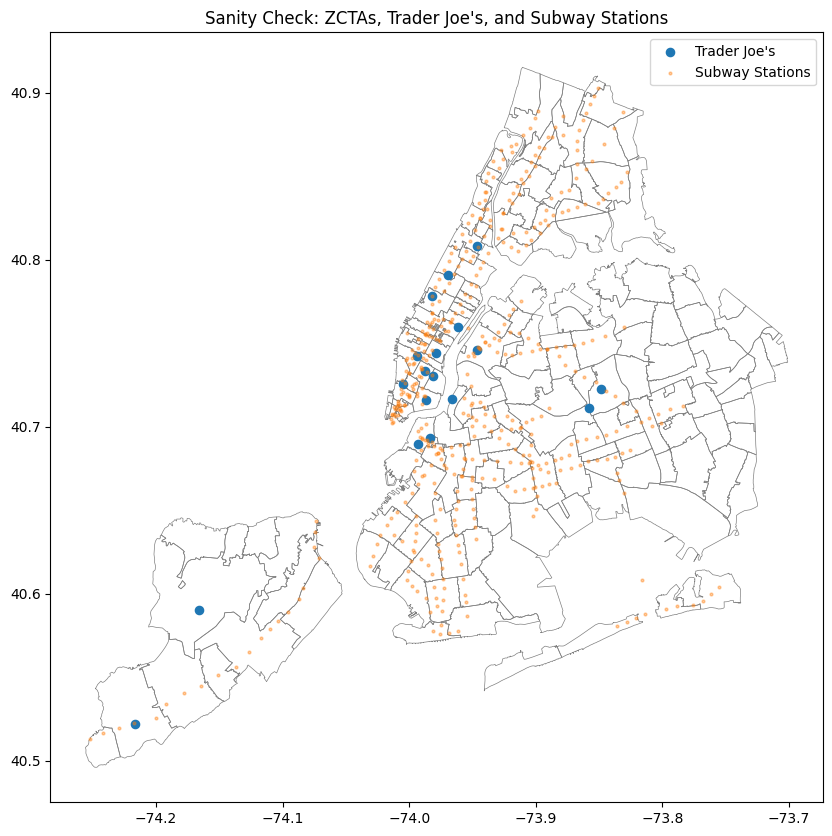

In [63]:
fig, ax = plt.subplots(figsize=(10, 10))

nyc_features_gdf.to_crs(epsg=4326).plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.5,
    label="NYC ZCTAs"
)

tj_gdf.to_crs(epsg=4326).plot(
    ax=ax,
    markersize=35,
    label="Trader Joe's"
)

subway_gdf.to_crs(epsg=4326).plot(
    ax=ax,
    markersize=4,
    alpha=0.4,
    label="Subway Stations"
)

plt.legend()
plt.title("Sanity Check: ZCTAs, Trader Joe's, and Subway Stations")
plt.show()

In [64]:
nyc_features_gdf.to_file(
    INTERIM_DIR / "nyc_features_clean.geojson",
    driver="GeoJSON"
)

nyc_features_gdf.drop(columns=["geometry"], errors="ignore").to_csv(
    INTERIM_DIR / "nyc_features_clean.csv",
    index=False
)

In [65]:
whole_foods_df = pd.read_csv(RAW_DIR / "whole_foods_nyc.csv")
wegmans_df = pd.read_csv(RAW_DIR / "wegmans_nyc.csv")

In [66]:
whole_foods_df = standardize_columns(whole_foods_df)
wegmans_df = standardize_columns(wegmans_df)

In [67]:
whole_foods_df["brand"] = "Whole Foods"
wegmans_df["brand"] = "Wegmans"

In [68]:
whole_foods_df["zip_code"] = whole_foods_df["zip_code"].astype(str).str.zfill(5)
wegmans_df["zip_code"] = wegmans_df["zip_code"].astype(str).str.zfill(5)

In [69]:
competitors_df = pd.concat([whole_foods_df, wegmans_df], ignore_index=True)

In [70]:
competitors_df["full_address"] = (
    competitors_df["address"] + ", " +
    competitors_df["borough"] + ", NY " +
    competitors_df["zip_code"]
)

In [71]:
print("shape:", competitors_df.shape)
print("brands:")
print(competitors_df["brand"].value_counts())
print("duplicate store_name:", competitors_df["store_name"].duplicated().sum())

competitors_df.head()

shape: (17, 9)
brands:
brand
Whole Foods    15
Wegmans         2
Name: count, dtype: int64
duplicate store_name: 0


,store_name,address,borough,zip_code,is_public_store,unnamed_5,brand,notes,full_address
0,Upper East Side,1551 3rd Ave,Manhattan,10128,1,NaN,Whole Foods,NaN,"1551 3rd Ave, Manhattan, NY 10128"
1,Lenox Hill,1175 3rd Ave,Manhattan,10065,1,NaN,Whole Foods,NaN,"1175 3rd Ave, Manhattan, NY 10065"
2,Midtown East,226 E 57th St,Manhattan,10022,1,NaN,Whole Foods,NaN,"226 E 57th St, Manhattan, NY 10022"
3,Bryant Park,1095 6th Ave,Manhattan,10036,1,NaN,Whole Foods,NaN,"1095 6th Ave, Manhattan, NY 10036"
4,Bowery,95 E Houston St,Manhattan,10002,1,NaN,Whole Foods,NaN,"95 E Houston St, Manhattan, NY 10002"


In [72]:
competitors_df = competitors_df.drop(columns = ['is_public_store', "notes"])

In [73]:
competitors_df.head()

,store_name,address,borough,zip_code,unnamed_5,brand,full_address
0,Upper East Side,1551 3rd Ave,Manhattan,10128,NaN,Whole Foods,"1551 3rd Ave, Manhattan, NY 10128"
1,Lenox Hill,1175 3rd Ave,Manhattan,10065,NaN,Whole Foods,"1175 3rd Ave, Manhattan, NY 10065"
2,Midtown East,226 E 57th St,Manhattan,10022,NaN,Whole Foods,"226 E 57th St, Manhattan, NY 10022"
3,Bryant Park,1095 6th Ave,Manhattan,10036,NaN,Whole Foods,"1095 6th Ave, Manhattan, NY 10036"
4,Bowery,95 E Houston St,Manhattan,10002,NaN,Whole Foods,"95 E Houston St, Manhattan, NY 10002"


In [74]:
from src.config import PROCESSED_DIR
competitors_df.to_csv(PROCESSED_DIR / "competitors_nyc.csv", index=False)

In [75]:
print(PROCESSED_DIR / "competitors_nyc.csv")

/Users/mihirgaudani/trader-joes-nyc-case-study/data/processed/competitors_nyc.csv


In [76]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [77]:
geolocator = Nominatim(user_agent="trader_joes_case_study_competitors")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [78]:
competitors_df["location"] = competitors_df["full_address"].apply(geocode)
competitors_df["latitude"] = competitors_df["location"].apply(lambda loc: loc.latitude if loc else None)
competitors_df["longitude"] = competitors_df["location"].apply(lambda loc: loc.longitude if loc else None)

In [79]:
print("missing latitude:", competitors_df["latitude"].isna().sum())
print("missing longitude:", competitors_df["longitude"].isna().sum())

competitors_df[[
    "brand",
    "store_name",
    "full_address",
    "latitude",
    "longitude"
]].head(10)

missing latitude: 1
missing longitude: 1


,brand,store_name,full_address,latitude,longitude
0,Whole Foods,Upper East Side,"1551 3rd Ave, Manhattan, NY 10128",40.779697,-73.952949
1,Whole Foods,Lenox Hill,"1175 3rd Ave, Manhattan, NY 10065",40.767301,-73.962166
2,Whole Foods,Midtown East,"226 E 57th St, Manhattan, NY 10022",40.759421,-73.966035
3,Whole Foods,Bryant Park,"1095 6th Ave, Manhattan, NY 10036",40.754649,-73.984811
4,Whole Foods,Bowery,"95 E Houston St, Manhattan, NY 10002",40.723848,-73.992371
5,Whole Foods,Union Square,"4 Union Square S, Manhattan, NY 10003",43.149030,-77.600428
6,Whole Foods,Tribeca,"270 Greenwich St, Manhattan, NY 10007",40.715611,-74.011738
7,Whole Foods,Columbus Circle,"10 Columbus Cir Ste Sc101, Manhattan, NY 10019",NaN,NaN
8,Whole Foods,Upper West Side,"808 Columbus Ave, Manhattan, NY 10025",40.794657,-73.966679
9,Whole Foods,NoMad,"63 Madison Ave, Manhattan, NY 10016",40.743626,-73.985749


In [80]:
competitors_df[
    competitors_df["latitude"].isna() |
    competitors_df["longitude"].isna() |
    ~competitors_df["latitude"].between(40.4, 41.0) |
    ~competitors_df["longitude"].between(-74.3, -73.6)
][["brand", "store_name", "full_address", "latitude", "longitude"]]

,brand,store_name,full_address,latitude,longitude
5,Whole Foods,Union Square,"4 Union Square S, Manhattan, NY 10003",43.14903,-77.600428
7,Whole Foods,Columbus Circle,"10 Columbus Cir Ste Sc101, Manhattan, NY 10019",NaN,NaN


In [81]:
competitors_df.loc[competitors_df["store_name"] == "Columbus Circle", "full_address"] = (
    "10 Columbus Circle, Manhattan, NY 10019"
)

competitors_df.loc[competitors_df["store_name"] == "Union Square", "full_address"] = (
    "4 Union Square South, Manhattan, NY 10003"
)

In [82]:
mask = competitors_df["store_name"].isin(["Columbus Circle", "Union Square"])

competitors_df.loc[mask, "location"] = competitors_df.loc[mask, "full_address"].apply(geocode)
competitors_df.loc[mask, "latitude"] = competitors_df.loc[mask, "location"].apply(
    lambda loc: loc.latitude if loc else None
)
competitors_df.loc[mask, "longitude"] = competitors_df.loc[mask, "location"].apply(
    lambda loc: loc.longitude if loc else None
)

In [83]:
print("missing latitude:", competitors_df["latitude"].isna().sum())
print("missing longitude:", competitors_df["longitude"].isna().sum())

competitors_df[competitors_df["store_name"].isin(["Columbus Circle", "Union Square"])][
    ["store_name", "full_address", "latitude", "longitude"]
]

missing latitude: 0
missing longitude: 0


,store_name,full_address,latitude,longitude
5,Union Square,"4 Union Square South, Manhattan, NY 10003",43.149037,-77.600424
7,Columbus Circle,"10 Columbus Circle, Manhattan, NY 10019",40.768255,-73.982852


In [84]:
mask = competitors_df["store_name"] == "Union Square"

competitors_df.loc[mask, "latitude"] = 40.735863
competitors_df.loc[mask, "longitude"] = -73.991084

In [85]:
competitors_df[competitors_df["store_name"].isin(["Union Square", "Columbus Circle"])][
    ["store_name", "full_address", "latitude", "longitude"]
]

,store_name,full_address,latitude,longitude
5,Union Square,"4 Union Square South, Manhattan, NY 10003",40.735863,-73.991084
7,Columbus Circle,"10 Columbus Circle, Manhattan, NY 10019",40.768255,-73.982852


In [86]:
competitor_gdf = gpd.GeoDataFrame(
    competitors_df,
    geometry=gpd.points_from_xy(competitors_df["longitude"], competitors_df["latitude"]),
    crs="EPSG:4326"
)

competitor_gdf.head()

,store_name,address,borough,zip_code,unnamed_5,brand,full_address,location,latitude,longitude,geometry
0,Upper East Side,1551 3rd Ave,Manhattan,10128,NaN,Whole Foods,"1551 3rd Ave, Manhattan, NY 10128","(Whole Foods Market, 1551, 3rd Avenue, Carnegi...",40.779697,-73.952949,POINT (-73.95295 40.7797)
1,Lenox Hill,1175 3rd Ave,Manhattan,10065,NaN,Whole Foods,"1175 3rd Ave, Manhattan, NY 10065","(1175, 3rd Avenue, Lenox Hill, Manhattan Commu...",40.767301,-73.962166,POINT (-73.96217 40.7673)
2,Midtown East,226 E 57th St,Manhattan,10022,NaN,Whole Foods,"226 E 57th St, Manhattan, NY 10022","(Whole Foods Market, 226, East 57th Street, Su...",40.759421,-73.966035,POINT (-73.96603 40.75942)
3,Bryant Park,1095 6th Ave,Manhattan,10036,NaN,Whole Foods,"1095 6th Ave, Manhattan, NY 10036","(Salesforce Tower, 1095, 6th Avenue, Midtown, ...",40.754649,-73.984811,POINT (-73.98481 40.75465)
4,Bowery,95 E Houston St,Manhattan,10002,NaN,Whole Foods,"95 E Houston St, Manhattan, NY 10002","(Whole Foods Market, 95, East Houston Street, ...",40.723848,-73.992371,POINT (-73.99237 40.72385)


In [87]:
competitors_df.drop(columns=["location"], errors="ignore").to_csv(
    PROCESSED_DIR / "competitors_nyc_geocoded.csv",
    index=False
)

competitor_gdf.to_file(
    PROCESSED_DIR / "competitors_nyc_geocoded.geojson",
    driver="GeoJSON"
)

# Summary

1. Loaded the core raw geographic and source datasets used in the project, including ZIP boundary geometry, borough boundaries, demographics, Trader Joe’s locations, and transit-related files.
2. Pulled ZIP-level demographic data from the ACS API and standardized key identifiers so all sources could be joined consistently at the ZIP-code level.
3. Geocoded Trader Joe’s store locations and converted raw coordinates/files into spatial tables for downstream geographic analysis.
4. Saved cleaned source datasets in a structured format so later notebooks could focus on cleaning, joins, and modeling rather than re-ingesting raw files.